In [2]:
import math
import numpy as np
import numpy.linalg as LA
import pandas as pd
import cv2
pd.set_option('display.max_columns', 200)  # Maximum number of columns to display
pd.set_option('display.max_colwidth', 200)  # Maximum width of column values

import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy

import networkx as nx

import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")

In [3]:
def softmax(array):
    # Subtract the max value from each row for numerical stability
    exp_array = np.exp(array - np.max(array, axis=1, keepdims=True))
    # Divide by the sum of the exponentials for each row
    return exp_array / np.sum(exp_array, axis=1, keepdims=True)

In [56]:
def create_graph(points):
    """Create a maximally connected planar graph using Delaunay triangulation."""
    # Perform Delaunay triangulation
    tri = scipy.spatial.Delaunay(points)
    
    G = nx.Graph()
    
    # Add nodes to the graph
    G.add_nodes_from(range(len(points)))
    
    # Add edges based on Delaunay triangulation
    for simplex in tri.simplices:
        for i in range(3):
            for j in range(i + 1, 3):
                G.add_edge(simplex[i], simplex[j])

    return G, nx.to_numpy_array(G)

def cosine_similarity(vec1, vec2):
    """
    Compute the cosine similarity between two vectors.
    
    Parameters:
        vec1 (ndarray): First vector.
        vec2 (ndarray): Second vector.
        
    Returns:
        float: Cosine similarity between vec1 and vec2.
    """
    # Dot product of the vectors
    dot_product = np.dot(vec1, vec2)
    # Magnitudes of the vectors
    magnitude1 = np.linalg.norm(vec1)
    magnitude2 = np.linalg.norm(vec2)
    # Avoid division by zero
    if magnitude1 == 0 or magnitude2 == 0:
        return 0.0
    return dot_product / (magnitude1 * magnitude2)

def cosine_similarity_matrix(matrix):
    """
    Compute the cosine similarity matrix for a 2D array.
    
    Parameters:
        matrix (ndarray): Input 2D array where rows are vectors.
        
    Returns:
        ndarray: Cosine similarity matrix (n x n).
    """
    # Compute dot product between all pairs of rows
    dot_product = np.dot(matrix, matrix.T)
    # Compute the norm of each row
    row_norms = np.linalg.norm(matrix, axis=1)
    # Outer product of norms for normalization
    norm_matrix = np.outer(row_norms, row_norms)
    # Avoid division by zero
    norm_matrix[norm_matrix == 0] = 1
    # Compute cosine similarity
    similarity_matrix = dot_product / norm_matrix
    return similarity_matrix

def plot_graph(G):
    %matplotlib inline
    
    # Draw the directed graph with custom arrow settings
    plt.figure(figsize=(10,10))
    #pos = nx.kamada_kawai_layout(G)  # Compute layout
    #pos = nx.fruchterman_reingold_layout(G)  # Compute layout
    pos = nx.spring_layout(G)  # Compute layout
    
    # Draw nodes and edges separately to customize arrows
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color='red',
        node_size=500
    )
    nx.draw_networkx_edges(
        G,
        pos,
        width=0.25,
        edge_color='white'
    )
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=20,
        font_color='white'
    )
    plt.axis('off')
    plt.show()

In [5]:
from mpl_toolkits.mplot3d import Axes3D

def plot_graph_3d(G):
    """
    Draw the directed graph in 3D with custom arrow settings.
    """
    %matplotlib qt
    
    plt.figure(figsize=(20, 20))
    
    # Compute 3D layout
    pos = nx.kamada_kawai_layout(G, dim=3)
    
    # Extract positions for nodes
    x, y, z = zip(*[pos[node] for node in G.nodes()])
    
    # Create a 3D plot
    ax = plt.axes(projection="3d")
    
    # Draw nodes
    ax.scatter(x, y, z, c='red', s=50, label='Nodes')
    
    # Draw edges
    for edge in G.edges():
        x_coords = [pos[edge[0]][0], pos[edge[1]][0]]
        y_coords = [pos[edge[0]][1], pos[edge[1]][1]]
        z_coords = [pos[edge[0]][2], pos[edge[1]][2]]
        ax.plot(x_coords, y_coords, z_coords, color='white', linewidth=0.5)
    
    # Turn off the axis
    ax.set_axis_off()
    plt.legend()
    plt.show()

In [ ]:
n_nodes = 5
emb_dim = 2

Z = np.random.randn(n_nodes,emb_dim)**2

#Z = np.zeros((n_nodes, emb_dim))
#Z[np.arange(n_nodes), np.random.randint(0, emb_dim, size=n_nodes)] = 1
#Z[np.arange(n_nodes), np.random.randint(0, emb_dim, size=n_nodes)] = 1

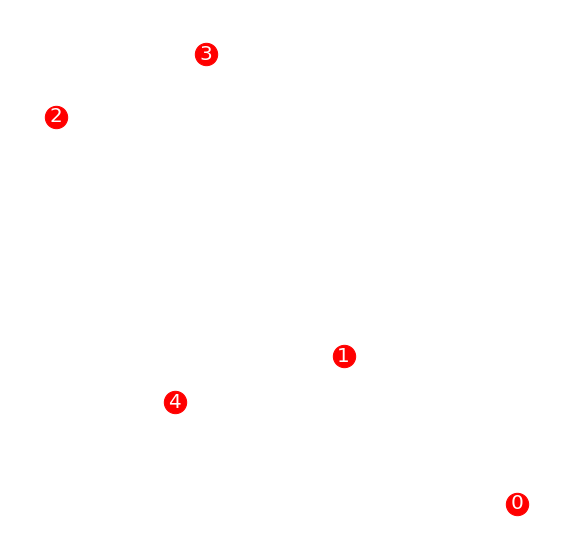

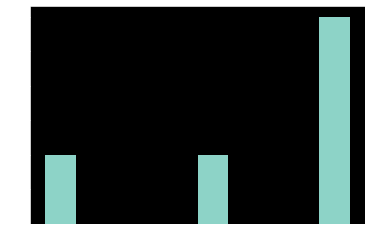

In [57]:
#W = np.dot(Z,Z.T)
#A = (W > np.quantile(W.flatten(),0.7)).astype(int)

W = cosine_similarity_matrix(Z)
A = (W > 0.75).astype(int) - np.eye(n_nodes)

#W = softmax(W)
#A = (W > 0.1).astype(int)

# Create the graph from the adjacency matrix
G = nx.from_numpy_matrix(A)

plot_graph(G)

plt.figure(figsize=(6,4))
plt.hist(A.sum(axis=0));

In [53]:
D = np.diag(A.sum(axis=1))
L = D - A
L = L / np.diag(D)[:,np.newaxis]
L

array([[ 1.        , -1.        ,  0.        ,  0.        ,  0.        ],
       [-0.33333333,  1.        ,  0.        , -0.33333333, -0.33333333],
       [ 0.        ,  0.        ,  1.        , -0.5       , -0.5       ],
       [ 0.        , -0.33333333, -0.33333333,  1.        , -0.33333333],
       [ 0.        , -0.33333333, -0.33333333, -0.33333333,  1.        ]])

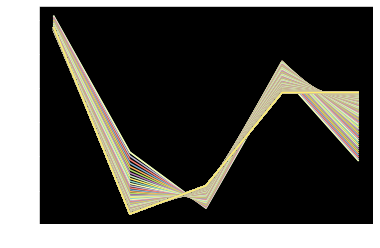

In [76]:
n_step = 1000
dt = 0.1

x = np.zeros((n_step,n_nodes))
x[0,:] = np.random.randn(n_nodes)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x[0,:] = scaler.fit_transform(x[0,:,None])[:,0]

plt.figure()
plt.plot(x[0,:])

for i in range(n_step-1):
    x[i+1,:] = x[i,:] + np.dot(L,x[i,:])*dt
    x[i+1,:] = scaler.fit_transform(x[i+1,:,None])[:,0]
    #plt.figure()
    plt.plot(x[i,:])
# end
#print(x.sum(axis=1))